In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from data_loading import clean_datasets
import torch
import torch.nn as nn
import itertools
import time
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


## Data-Loading and Training Folds

In [2]:
DATASET_CONFIG = {
    "motor-temp":         {"window": 75,  "transform": "diff",        "n_folds": 5},
    "wind-power":          {"window": 36,  "transform": "diff",        "n_folds": 5},
    "store-sales":         {"window": 7,   "transform": "log1p_diff",  "n_folds": 5},
    "antarctica-climate":  {"window": 30,  "transform": "diff",        "n_folds": 5},
    "traffic":             {"window": 24,  "transform": "diff",        "n_folds": 5},
}

SERIES = clean_datasets()

In [3]:
def apply_transform(series, transform):
    s = series.dropna()
    if transform == "log1p_diff":
        s = np.log1p(s)
        return s.diff().dropna()
    elif transform == "diff":
        return s.diff().dropna()
    elif transform == "none":
        return s
    else:
        raise ValueError(f"unknown transform: {transform}")

In [4]:
TRANSFORMED_FINAL = {}
for name, s in SERIES.items():
    cfg = DATASET_CONFIG[name]
    TRANSFORMED_FINAL[name] = apply_transform(s, cfg["transform"])
    print(f"{name}: transform='{cfg['transform']}', n={len(TRANSFORMED_FINAL[name])}")


motor-temp: transform='diff', n=43970
wind-power: transform='diff', n=5038
store-sales: transform='log1p_diff', n=1457
antarctica-climate: transform='diff', n=7304
traffic: transform='diff', n=17543


In [5]:
def make_windows(values, window):
    """
    values: 1D numpy array
    window: number of past steps used to predict the next step
    Returns X of shape (n_samples, window, 1), y of shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i : i + window])
        y.append(values[i + window])
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y)
    return X, y

In [6]:
def walk_forward_splits(n_samples, n_folds, min_train_fraction=0.4):
    """
    Yields (train_idx, val_idx) index ranges for expanding-window walk-forward CV.
    min_train_fraction: fraction of data used as the initial training block.
    Remaining data is split into n_folds equal validation chunks, each fold's
    training set expanding to include all prior folds' data.
    """
    min_train_size = int(n_samples * min_train_fraction)
    remaining = n_samples - min_train_size
    fold_size = remaining // n_folds

    splits = []
    for fold in range(n_folds):
        train_end = min_train_size + fold * fold_size
        val_start = train_end
        val_end = val_start + fold_size if fold < n_folds - 1 else n_samples
        splits.append((np.arange(0, train_end), np.arange(val_start, val_end)))
    return splits

In [ ]:
PREPARED = {}

for name, series in TRANSFORMED_FINAL.items():
    cfg = DATASET_CONFIG[name]
    values = series.values.astype(np.float64)

    X, y = make_windows(values, cfg["window"])
    splits = walk_forward_splits(len(X), cfg["n_folds"])

    fold_data = []
    for fold_i, (train_idx, val_idx) in enumerate(splits):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        # fit scaler on training data
        scaler = MinMaxScaler(feature_range=(-1, 1))
        scaler.fit(X_train.reshape(-1, 1))

        X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
        X_val_scaled   = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
        y_train_scaled = scaler.transform(y_train.reshape(-1, 1)).flatten()
        y_val_scaled   = scaler.transform(y_val.reshape(-1, 1)).flatten()

        fold_data.append({
            "X_train": X_train_scaled, "y_train": y_train_scaled,
            "X_val": X_val_scaled,     "y_val": y_val_scaled,
            "scaler": scaler,
            "train_size": len(train_idx), "val_size": len(val_idx),
        })

    PREPARED[name] = fold_data

    print(f"\n{name}: window={cfg['window']}, total windows={len(X)}, folds={cfg['n_folds']}")
    for i, f in enumerate(fold_data):
        print(f"  fold {i}: train={f['train_size']}, val={f['val_size']}")


motor-temp: window=75, total windows=43895, folds=5
  fold 0: train=17558, val=5267
  fold 1: train=22825, val=5267
  fold 2: train=28092, val=5267
  fold 3: train=33359, val=5267
  fold 4: train=38626, val=5269

wind-power: window=36, total windows=5002, folds=5
  fold 0: train=2000, val=600
  fold 1: train=2600, val=600
  fold 2: train=3200, val=600
  fold 3: train=3800, val=600
  fold 4: train=4400, val=602

store-sales: window=7, total windows=1450, folds=5
  fold 0: train=580, val=174
  fold 1: train=754, val=174
  fold 2: train=928, val=174
  fold 3: train=1102, val=174
  fold 4: train=1276, val=174

antarctica-climate: window=30, total windows=7274, folds=5
  fold 0: train=2909, val=873
  fold 1: train=3782, val=873
  fold 2: train=4655, val=873
  fold 3: train=5528, val=873
  fold 4: train=6401, val=873

traffic: window=24, total windows=17519, folds=5
  fold 0: train=7007, val=2102
  fold 1: train=9109, val=2102
  fold 2: train=11211, val=2102
  fold 3: train=13313, val=2102


In [ ]:
# Checking no NaN's in dataset
for name, folds in PREPARED.items():
    for i, f in enumerate(folds):
        bad = (np.isnan(f["X_train"]).any() or np.isnan(f["y_train"]).any()
               or np.isinf(f["X_train"]).any() or np.isinf(f["y_train"]).any())
        if bad:
            print(f"⚠ {name} fold {i}: NaN/Inf detected")
print("NaN/Inf check complete")

# Checking the ranges look correct
for name, folds in PREPARED.items():
    f = folds[-1]
    print(f"{name}: y_train range=({f['y_train'].min():.2f}, {f['y_train'].max():.2f}), "
          f"y_val range=({f['y_val'].min():.2f}, {f['y_val'].max():.2f})")

NaN/Inf check complete
motor-temp: y_train range=(-1.00, 1.00), y_val range=(-0.65, 0.16)
wind-power: y_train range=(-1.00, 1.00), y_val range=(-0.55, 0.56)
store-sales: y_train range=(-1.00, 1.00), y_val range=(-0.92, 0.90)
antarctica-climate: y_train range=(-1.00, 1.00), y_val range=(-0.66, 0.65)
traffic: y_train range=(-1.00, 1.00), y_val range=(-0.97, 1.37)


## Modelling

### Class Definition

In [10]:
# ---------------------------------------------------------------
# Elman Network — feedback from previous HIDDEN state
# (equivalent to nn.RNN, but written explicitly so it can be
#  described precisely in the report and kept consistent in
#  style with Jordan/MRN below)
# ---------------------------------------------------------------
class ElmanNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_context = nn.Linear(hidden_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            h = self.activation(self.W_in(x[:, t, :]) + self.W_context(h))
            # context units simply ARE h at the next step — no separate state needed

        out = self.W_out(h)
        return out.squeeze(-1)


# ---------------------------------------------------------------
# Jordan Network — feedback from previous OUTPUT
# ---------------------------------------------------------------
class JordanNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_context = nn.Linear(output_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        y_prev = torch.zeros(batch_size, self.output_size, device=x.device)

        for t in range(seq_len):
            h = self.activation(self.W_in(x[:, t, :]) + self.W_context(y_prev))
            y_prev = self.W_out(h)  # context is the network's own previous output

        return y_prev.squeeze(-1)


# ---------------------------------------------------------------
# Multi-Recurrent Network — feedback from BOTH hidden state and
# output, with a self-recurrent decay parameter on the context
# units for multi-timescale memory (Elman + Jordan generalized)
# ---------------------------------------------------------------
class MultiRecurrentNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1, decay=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.decay = decay  # controls how much of the PAST context persists

        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_hidden_context = nn.Linear(hidden_size, hidden_size)
        self.W_output_context = nn.Linear(output_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        y_prev = torch.zeros(batch_size, self.output_size, device=x.device)
        context_h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            # self-recurrent context: decayed mix of past context + new hidden activation
            context_h = self.decay * context_h + (1 - self.decay) * h
            h = self.activation(
                self.W_in(x[:, t, :])
                + self.W_hidden_context(context_h)
                + self.W_output_context(y_prev)
            )
            y_prev = self.W_out(h)

        return y_prev.squeeze(-1)

In [11]:
def train_model(model, X_train, y_train, X_val, y_val,
                 lr=1e-3, weight_decay=1e-4, max_epochs=200, patience=15, device="cpu"):

    model = model.to(device)
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32, device=device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # guards against exploding gradients
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = loss_fn(val_pred, y_val_t).item()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

Smoke test: ElmanNet on 'motor-temp', fold 0
X_train shape: (17558, 75, 1), y_train shape: (17558,)
X_val shape:   (5267, 75, 1), y_val shape:   (5267,)
  early stopping at epoch 36

Done in 6.5s, 37 epochs run
Best val loss: 0.011195
Final train loss: 0.008709


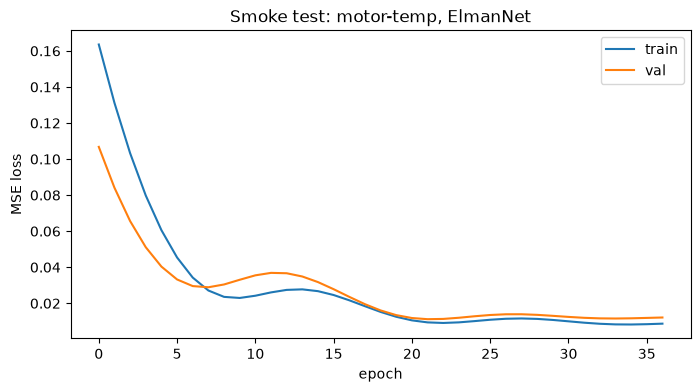


Naive (predict-zero) baseline val MSE: 0.114407
Model val MSE:                          0.011195
Model beats the naive baseline


In [ ]:
# ---------------------------------------------------------------
# Smoke test: one architecture, one dataset, one fold
# ---------------------------------------------------------------
name = "motor-temp"
fold = PREPARED[name][0]

print(f"Smoke test: ElmanNet on '{name}', fold 0")
print(f"X_train shape: {fold['X_train'].shape}, y_train shape: {fold['y_train'].shape}")
print(f"X_val shape:   {fold['X_val'].shape}, y_val shape:   {fold['y_val'].shape}")

model = ElmanNet(input_size=1, hidden_size=32, output_size=1)

start = time.time()
trained_model, history, best_val_loss = train_model(
    model,
    fold["X_train"], fold["y_train"],
    fold["X_val"], fold["y_val"],
    lr=1e-3, weight_decay=1e-4,
    max_epochs=200, patience=15,
)
elapsed = time.time() - start

print(f"\nDone in {elapsed:.1f}s, {len(history['train_loss'])} epochs run")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Final train loss: {history['train_loss'][-1]:.6f}")

# quick sanity plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.legend()
plt.title(f"Smoke test: {name}, ElmanNet")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

# a second sanity check: does the model actually beat a naive baseline?
# naive baseline: predict "no change" (0, since data is differenced)
naive_val_loss = np.mean(fold["y_val"] ** 2)
print(f"\nNaive (predict-zero) baseline val MSE: {naive_val_loss:.6f}")
print(f"Model val MSE:                          {best_val_loss:.6f}")
print(f"Model {'beats' if best_val_loss < naive_val_loss else 'DOES NOT beat'} the naive baseline")

### GridSearch

In [15]:
# ---------------------------------------------------------------
# 1. Model registry — architecture name -> class + which kwargs it accepts
# ---------------------------------------------------------------
ARCHITECTURES = {
    "elman": ElmanNet,
    "jordan": JordanNet,
    "mrn": MultiRecurrentNet,
}

# ---------------------------------------------------------------
# 2. Hyperparameter grid — kept small deliberately given time constraints.
#    MRN gets an extra 'decay' parameter; others ignore it via **kwargs filtering.
# ---------------------------------------------------------------
HIDDEN_SIZES = [16, 32, 64]
WEIGHT_DECAYS = [0.0, 1e-4, 1e-3]
MRN_DECAYS = [0.3, 0.5, 0.7]

def build_model(arch_name, hidden_size, decay=0.5):
    cls = ARCHITECTURES[arch_name]
    if arch_name == "mrn":
        return cls(input_size=1, hidden_size=hidden_size, output_size=1, decay=decay)
    else:
        return cls(input_size=1, hidden_size=hidden_size, output_size=1)

# ---------------------------------------------------------------
# 3. Hyperparameter search — run ONCE per (dataset, architecture) on fold 0,
#    picking the config with best validation loss. This avoids re-searching
#    per fold, which would be prohibitively slow.
# ---------------------------------------------------------------
def hyperparam_search(arch_name, dataset_name, fold0, max_epochs=150, patience=10):
    best_cfg, best_loss = None, float("inf")

    if arch_name == "mrn":
        grid = list(itertools.product(HIDDEN_SIZES, WEIGHT_DECAYS, MRN_DECAYS))
    else:
        grid = [(h, wd, None) for h, wd in itertools.product(HIDDEN_SIZES, WEIGHT_DECAYS)]

    for hidden_size, weight_decay, decay in grid:
        model = build_model(arch_name, hidden_size, decay if decay is not None else 0.5)
        _, _, val_loss = train_model(
            model, fold0["X_train"], fold0["y_train"], fold0["X_val"], fold0["y_val"],
            lr=1e-3, weight_decay=weight_decay, max_epochs=max_epochs, patience=patience,
        )
        if val_loss < best_loss:
            best_loss = val_loss
            best_cfg = {"hidden_size": hidden_size, "weight_decay": weight_decay, "decay": decay}

    return best_cfg, best_loss

# ---------------------------------------------------------------
# 4. Full experiment: for each dataset x architecture, search hyperparams
#    once, then retrain+evaluate with that config across ALL folds.
# ---------------------------------------------------------------
RESULTS = []          # flat list of per-fold results, for stats testing
BEST_CONFIGS = {}      # (dataset, arch) -> chosen hyperparameters

overall_start = time.time()

for dataset_name, folds in PREPARED.items():
    for arch_name in ARCHITECTURES:
        print(f"\n{'='*60}\n{dataset_name} | {arch_name}\n{'='*60}")

        # --- hyperparameter search on fold 0 ---
        t0 = time.time()
        best_cfg, search_val_loss = hyperparam_search(arch_name, dataset_name, folds[0])
        BEST_CONFIGS[(dataset_name, arch_name)] = best_cfg
        print(f"  best config: {best_cfg} (search val loss={search_val_loss:.6f}, "
              f"took {time.time()-t0:.1f}s)")

        # --- evaluate chosen config across ALL folds ---
        for fold_i, fold in enumerate(folds):
            model = build_model(
                arch_name, best_cfg["hidden_size"],
                best_cfg["decay"] if best_cfg["decay"] is not None else 0.5,
            )
            trained_model, history, val_loss = train_model(
                model, fold["X_train"], fold["y_train"], fold["X_val"], fold["y_val"],
                lr=1e-3, weight_decay=best_cfg["weight_decay"],
                max_epochs=200, patience=15,
            )

            # compute additional metrics beyond MSE for reporting
            with torch.no_grad():
                X_val_t = torch.tensor(fold["X_val"], dtype=torch.float32)
                y_val_t = torch.tensor(fold["y_val"], dtype=torch.float32)
                pred = trained_model(X_val_t).numpy()

            mse = np.mean((pred - fold["y_val"]) ** 2)
            mae = np.mean(np.abs(pred - fold["y_val"]))
            rmse = np.sqrt(mse)

            RESULTS.append({
                "dataset": dataset_name, "arch": arch_name, "fold": fold_i,
                "mse": mse, "mae": mae, "rmse": rmse,
                "hidden_size": best_cfg["hidden_size"],
                "weight_decay": best_cfg["weight_decay"],
                "decay": best_cfg["decay"],
            })
            print(f"    fold {fold_i}: MSE={mse:.6f}, MAE={mae:.6f}, RMSE={rmse:.6f}")

print(f"\n\nTotal time: {(time.time()-overall_start)/60:.1f} minutes")

RESULTS_DF = pd.DataFrame(RESULTS)
RESULTS_DF.to_csv("results_raw.csv", index=False)
print("\nSaved to results_raw.csv")


motor-temp | elman
  early stopping at epoch 72
  early stopping at epoch 70
  early stopping at epoch 33
  early stopping at epoch 31
  early stopping at epoch 25
  early stopping at epoch 15
  early stopping at epoch 20
  early stopping at epoch 23
  best config: {'hidden_size': 32, 'weight_decay': 0.0001, 'decay': None} (search val loss=0.010101, took 69.0s)
  early stopping at epoch 47
    fold 0: MSE=0.011142, MAE=0.077244, RMSE=0.105557
  early stopping at epoch 33
    fold 1: MSE=0.003872, MAE=0.047649, RMSE=0.062224
  early stopping at epoch 42
    fold 2: MSE=0.004584, MAE=0.053104, RMSE=0.067707
  early stopping at epoch 42
    fold 3: MSE=0.005729, MAE=0.057521, RMSE=0.075690
  early stopping at epoch 37
    fold 4: MSE=0.005187, MAE=0.056281, RMSE=0.072022

motor-temp | jordan
  early stopping at epoch 12
  early stopping at epoch 56
  early stopping at epoch 94
  early stopping at epoch 72
  early stopping at epoch 85
  early stopping at epoch 58
  best config: {'hidden_s

In [19]:
# Friedman test: are the 3 architectures significantly different, averaged across datasets?
pivot = RESULTS_DF.groupby(["dataset", "arch"])["rmse"].mean().unstack()
print(pivot)

stat, p = friedmanchisquare(pivot["elman"], pivot["jordan"], pivot["mrn"])
print(f"\nFriedman test: stat={stat:.4f}, p={p:.4f}")

if p < 0.05:
    print("Significant difference detected — running pairwise Wilcoxon tests:")
    for a, b in itertools.combinations(["elman", "jordan", "mrn"], 2):
        w_stat, w_p = wilcoxon(pivot[a], pivot[b])
        print(f"  {a} vs {b}: stat={w_stat:.4f}, p={w_p:.4f}")

arch                   elman    jordan       mrn
dataset                                         
antarctica-climate  0.157468  0.166019  0.158466
motor-temp          0.076640  0.099617  0.071281
store-sales         0.258157  0.298796  0.261117
traffic             0.065109  0.074482  0.059951
wind-power          0.151023  0.151025  0.150201

Friedman test: stat=7.6000, p=0.0224
Significant difference detected — running pairwise Wilcoxon tests:
  elman vs jordan: stat=0.0000, p=0.0625
  elman vs mrn: stat=5.0000, p=0.6250
  jordan vs mrn: stat=0.0000, p=0.0625
